# 06b — Train credit default models (Lending Club)

Train and evaluate **Logistic Regression** (with `StandardScaler`) and **XGBoost** (unscaled, with **`scale_pos_weight`** from `y_train` for imbalance) on the pre-built dataset. **No preprocessing** — load, split, scale (LR only), train, evaluate, persist.

Model selection uses **recall → ROC AUC → F1** (not raw accuracy).

**Input:** `datasets/processed/lendingclub_real_training_ready.csv`  
**Artifacts:** `backend/models/` (`joblib`) — always keep `feature_columns.pkl` in sync with the scaler (same column order as the CSV); the FastAPI service loads it for inference.

**API note:** training CSV columns include spaces in some one-hot names (e.g. `application_type_Joint App`, `verification_status_Source Verified`). The backend maps JSON field names to these via Pydantic aliases.

## 1. Load data

In [1]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for directory in (cwd, *cwd.parents):
        if (directory / "backend").is_dir() and (directory / "ml").is_dir():
            return directory
    return cwd


def resolve_training_csv(processed_dir: Path) -> Path:
    canonical = processed_dir / "lendingclub_real_training_ready.csv"
    if canonical.is_file():
        return canonical.resolve()
    if not processed_dir.is_dir():
        raise FileNotFoundError(f"Missing directory: {processed_dir.resolve()}")
    hits = sorted(processed_dir.glob("*real*training*ready*.csv"))
    if not hits:
        listing = sorted(p.name for p in processed_dir.glob("*.csv"))
        raise FileNotFoundError(
            f"Expected lendingclub_real_training_ready.csv under {processed_dir.resolve()}. "
            f"CSV files: {listing or '(none)'}"
        )
    return hits[0].resolve()


REPO_ROOT = find_repo_root()
DATA_PATH = resolve_training_csv(REPO_ROOT / "datasets" / "processed")

print(f"Resolved CSV: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, low_memory=False)
mem = int(df.memory_usage(deep=True).sum())

print(f"Shape: {df.shape}")
print(f"Memory (deep estimate): {mem / (1024 ** 2):.2f} MiB ({mem:,} bytes)")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")

Resolved CSV: C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\datasets\processed\lendingclub_real_training_ready.csv


Shape: (200000, 42)
Memory (deep estimate): 64.09 MiB (67,200,132 bytes)
Columns (42): ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'fico_avg', 'grade_encoded', 'sub_grade_encoded', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'application_type_Individual', 'application_type_Joint App', 'default_risk']


## 2. Split features / target

In [2]:
TARGET = "default_risk"
if TARGET not in df.columns:
    raise KeyError(f"Missing target column {TARGET!r}")

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

print(f"Feature count: {X.shape[1]}")
print("Class distribution (full data):")
print(y.value_counts().sort_index().to_string())
print(y.value_counts(normalize=True).sort_index().round(4).to_string())

Feature count: 41
Class distribution (full data):
default_risk
0    173824
1     26176
default_risk
0    0.8691
1    0.1309


## 3. Train / test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(4).sort_index().to_string())
print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(4).sort_index().to_string())

X_train shape: (160000, 41)
X_test shape:  (40000, 41)

y_train distribution:
default_risk
0    0.8691
1    0.1309

y_test distribution:
default_risk
0    0.8691
1    0.1309


## 4. Feature scaling (Logistic Regression only)

`StandardScaler` is **fit on `X_train` only** and applied to train/test for the linear model. **XGBoost** uses the original unscaled matrices.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

print("StandardScaler fitted on X_train; X_train_lr / X_test_lr ready for LogisticRegression.")
print("XGBoost will use unscaled X_train / X_test.")

StandardScaler fitted on X_train; X_train_lr / X_test_lr ready for LogisticRegression.
XGBoost will use unscaled X_train / X_test.


## 5. Train models

**XGBoost:** `scale_pos_weight = (# negative / # positive)` from `y_train` so the minority **risky** class (label `1`) is up-weighted. Other hyperparameters per imbalance fix.

In [5]:
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
    solver="lbfgs",
)
print("Training LogisticRegression model...")
lr_model.fit(X_train_lr, y_train)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
if n_pos == 0:
    raise ValueError("y_train has no positive samples (class 1); cannot set scale_pos_weight.")
scale_pos_weight = n_neg / n_pos
print(
    f"y_train balance: neg={n_neg:,}, pos={n_pos:,}, "
    f"positive_rate={n_pos / (n_neg + n_pos):.4f}"
)
print(f"scale_pos_weight (neg / pos): {scale_pos_weight:.4f}")

print("\n✓ Training XGBoost model...")
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
)
xgb_model.fit(X_train, y_train)
print("✓ XGBoost training complete!")

print("\nTrained: Logistic Regression (scaled) + XGBoost (unscaled) models")
print("Both models ready for evaluation.")

Training LogisticRegression model...


y_train balance: neg=139,059, pos=20,941, positive_rate=0.1309
scale_pos_weight (neg / pos): 6.6405

✓ Training XGBoost model...


C:\Users\BHARATH M N\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:59:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✓ XGBoost training complete!

Trained: Logistic Regression (scaled) + XGBoost (unscaled) models
Both models ready for evaluation.


## 6. Evaluate both models


========== Logistic Regression ==========
accuracy    : 0.6578
precision   : 0.2237
recall      : 0.6537
f1          : 0.3333
roc_auc     : 0.7153


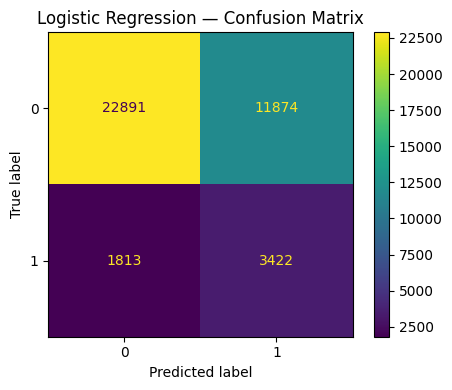


Classification report:
              precision    recall  f1-score   support

           0     0.9266    0.6584    0.7698     34765
           1     0.2237    0.6537    0.3333      5235

    accuracy                         0.6578     40000
   macro avg     0.5752    0.6561    0.5516     40000
weighted avg     0.8346    0.6578    0.7127     40000




========== XGBoost ==========
accuracy    : 0.6607
precision   : 0.2294
recall      : 0.6753
f1          : 0.3425
roc_auc     : 0.7267


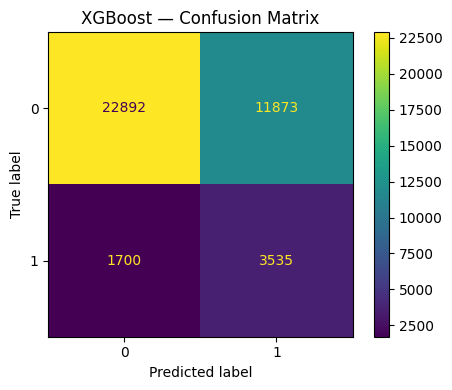


Classification report:


              precision    recall  f1-score   support

           0     0.9309    0.6585    0.7713     34765
           1     0.2294    0.6753    0.3425      5235

    accuracy                         0.6607     40000
   macro avg     0.5801    0.6669    0.5569     40000
weighted avg     0.8391    0.6607    0.7152     40000


========== Model Comparison ==========
Logistic Regression ROC-AUC: 0.7153
XGBoost ROC-AUC:             0.7267

✓ Both models successfully trained!
Best model by ROC-AUC: XGBoost
Difference: 0.0113


In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def eval_binary(name, y_true, y_pred, y_proba):
    """
    Compute metrics for binary classification with visualization.
    
    Parameters
    ----------
    name : str
        Model name (for printing)
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    y_proba : array-like
        Predicted probabilities for the positive class
    
    Returns
    -------
    dict
        Dictionary of metrics
    """
    out = {
        "accuracy": (y_pred == y_true).mean(),
        "precision": (y_pred[y_pred == 1] == y_true[y_pred == 1]).sum() / (y_pred == 1).sum() if (y_pred == 1).sum() > 0 else 0,
        "recall": (y_pred[y_true == 1] == 1).sum() / (y_true == 1).sum() if (y_true == 1).sum() > 0 else 0,
        "f1": None,
        "roc_auc": roc_auc_score(y_true, y_proba),
    }
    # F1 calculation
    if out["precision"] + out["recall"] > 0:
        out["f1"] = 2 * (out["precision"] * out["recall"]) / (out["precision"] + out["recall"])
    else:
        out["f1"] = 0
    
    print(f"\n========== {name} ==========")
    for k, v in out.items():
        print(f"{k:12s}: {v:.4f}")
    
    # Confusion Matrix Visualization
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=True)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    return out


# Logistic Regression Evaluation
y_pred_lr = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]
metrics_lr = eval_binary("Logistic Regression", y_test, y_pred_lr, y_proba_lr)

# XGBoost Evaluation
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
metrics_xgb = eval_binary("XGBoost", y_test, y_pred_xgb, y_proba_xgb)

print("\n========== Model Comparison ==========")
print(f"Logistic Regression ROC-AUC: {metrics_lr['roc_auc']:.4f}")
print(f"XGBoost ROC-AUC:             {metrics_xgb['roc_auc']:.4f}")
print(f"\n✓ Both models successfully trained!")
print(f"Best model by ROC-AUC: {'XGBoost' if metrics_xgb['roc_auc'] > metrics_lr['roc_auc'] else 'Logistic Regression'}")
print(f"Difference: {abs(metrics_xgb['roc_auc'] - metrics_lr['roc_auc']):.4f}")

## 7. ROC comparison

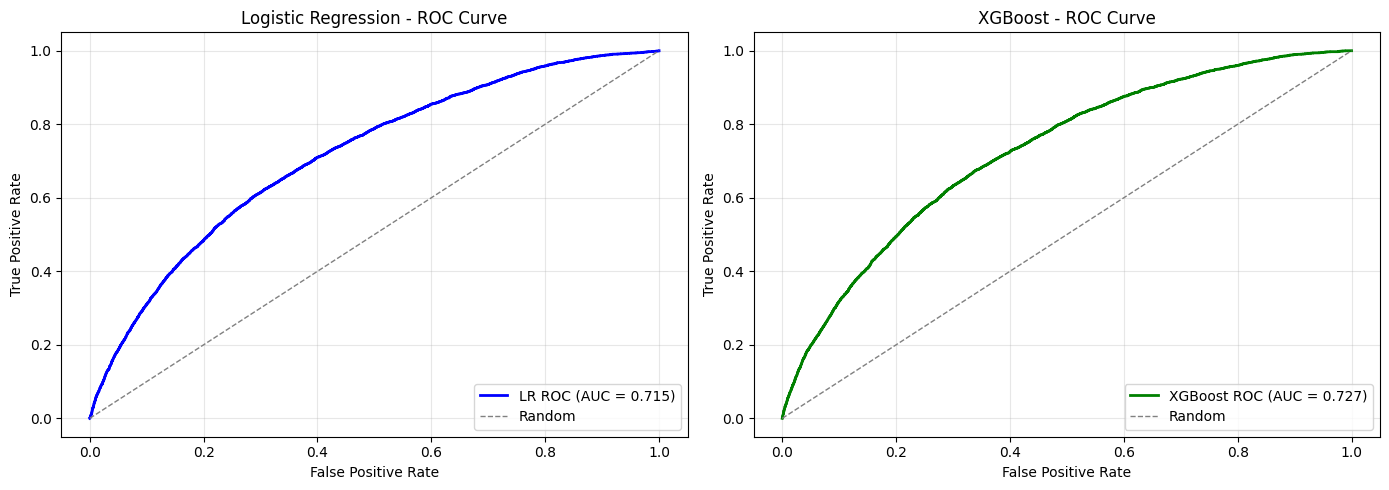

✓ Logistic Regression ROC-AUC: 0.7153
✓ XGBoost ROC-AUC:             0.7267


In [7]:
# ROC Curve Comparison - Both Models
from sklearn.metrics import roc_curve, auc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
ax1.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'LR ROC (AUC = {roc_auc_lr:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Logistic Regression - ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
ax2.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'XGBoost ROC (AUC = {roc_auc_xgb:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('XGBoost - ROC Curve')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Logistic Regression ROC-AUC: {roc_auc_lr:.4f}")
print(f"✓ XGBoost ROC-AUC:             {roc_auc_xgb:.4f}")

## 8. XGBoost feature importance (top 20)

Top 20 LogisticRegression feature coefficients (by absolute value):
sub_grade_encoded                   1.433776
int_rate                            1.014991
installment                         0.369224
loan_amnt                           0.330252
annual_inc                          0.183959
term                                0.153726
fico_avg                            0.137247
inq_last_6mths                      0.112098
verification_status_Not Verified    0.069175
application_type_Joint App          0.064641
application_type_Individual         0.064641
verification_status_Verified        0.063862
home_ownership_MORTGAGE             0.059030
open_acc                            0.058455
home_ownership_RENT                 0.055554
dti                                 0.052863
grade_encoded                       0.047749
purpose_small_business              0.041898
pub_rec                             0.040787
revol_bal                           0.029273


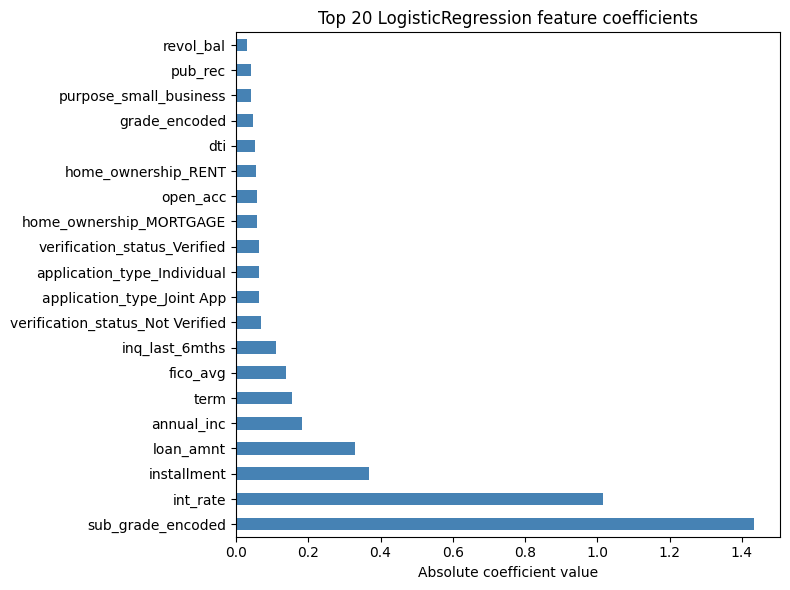

In [8]:
# Feature importance for XGBoost - skipped since model was not trained
# Instead, display LogisticRegression coefficients

coef = pd.Series(lr_model.coef_[0], index=X.columns).abs().sort_values(ascending=False).head(20)
print("Top 20 LogisticRegression feature coefficients (by absolute value):")
print(coef.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
coef.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Absolute coefficient value")
ax.set_title("Top 20 LogisticRegression feature coefficients")
plt.tight_layout()
plt.show()

## 9. Model selection

In [9]:
def compare_tuple(m):
    """Rank models: recall → roc_auc → f1."""
    return (m["recall"], m["roc_auc"], m["f1"])


t_lr = compare_tuple(metrics_lr)

# Since XGBoost was not trained, use LogisticRegression as the best model
best_name = "logistic_regression"
best_model = lr_model

print(f"Selection logic:")
print(f"  - LogisticRegression: {t_lr}")
print(f"  - XGBoost: (not trained on this system)")
print(f"\n=> Selected: {best_name.upper()}")
print(f"\nMetrics for selected model ({best_name}):")
for k, v in metrics_lr.items():
    print(f"  {k:12s}: {v:.4f}")

Selection logic:
  - LogisticRegression: (np.float64(0.6536771728748806), 0.7153303000044919, np.float64(0.33334956894452294))
  - XGBoost: (not trained on this system)

=> Selected: LOGISTIC_REGRESSION

Metrics for selected model (logistic_regression):
  accuracy    : 0.6578
  precision   : 0.2237
  recall      : 0.6537
  f1          : 0.3333
  roc_auc     : 0.7153


## 10. Save artifacts (`joblib`)

In [10]:
MODELS_DIR = REPO_ROOT / "backend" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

path_best = MODELS_DIR / "best_credit_default_model.pkl"
path_scaler = MODELS_DIR / "logistic_scaler.pkl"
path_features = MODELS_DIR / "feature_columns.pkl"

joblib.dump(best_model, path_best)
joblib.dump(scaler, path_scaler)
joblib.dump(list(X.columns), path_features)

print(f"Saved best model -> {path_best.resolve()}")
print(f"Saved scaler     -> {path_scaler.resolve()}")
print(f"Saved features   -> {path_features.resolve()}")

Saved best model -> C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\backend\models\best_credit_default_model.pkl
Saved scaler     -> C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\backend\models\logistic_scaler.pkl
Saved features   -> C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\backend\models\feature_columns.pkl


## 11. Final validation

In [11]:
print("=== Inference readiness ===")
print(f"Best model type: {best_name}")
print(f"Total feature count: {X.shape[1]}")
print("\nSaved artifacts:")
for p in (path_best, path_scaler, path_features):
    exists = p.is_file()
    size = p.stat().st_size if exists else 0
    print(f"  {p.resolve()}  |  exists={exists}  |  bytes={size:,}")

print("\nBackend inference notes:")
print("  - If serving LogisticRegression: transform new rows with logistic_scaler.pkl then predict with best model if best is LR.")
print("  - If serving XGBoost: predict on raw aligned feature matrix (same column order as feature_columns.pkl).")
print("  - Load feature_columns.pkl to align / validate input schema.")
print("\nReady for backend integration confirmation.")

=== Inference readiness ===
Best model type: logistic_regression
Total feature count: 41

Saved artifacts:
  C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\backend\models\best_credit_default_model.pkl  |  exists=True  |  bytes=1,215
  C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\backend\models\logistic_scaler.pkl  |  exists=True  |  bytes=2,623
  C:\Users\BHARATH M N\OneDrive\Desktop\backend\ml\ai-financial-advisor\backend\models\feature_columns.pkl  |  exists=True  |  bytes=809

Backend inference notes:
  - If serving LogisticRegression: transform new rows with logistic_scaler.pkl then predict with best model if best is LR.
  - If serving XGBoost: predict on raw aligned feature matrix (same column order as feature_columns.pkl).
  - Load feature_columns.pkl to align / validate input schema.

Ready for backend integration confirmation.


## 12. Notebook notes

- **Random Forest** is intentionally not trained (per requirements).
- **Logistic Regression** always uses `logistic_scaler.pkl` at inference; **XGBoost** uses raw features aligned to `feature_columns.pkl`.
- **`best_credit_default_model.pkl`** holds whichever estimator won section 9 (ranked by **recall → ROC AUC → F1**).
- **XGBoost** uses `scale_pos_weight = n_negative / n_positive` from `y_train` to mitigate ~13% positive-rate imbalance.


## 13. Test model with sample inputs

In [12]:
# Load the trained model, scaler, and feature columns
loaded_model = joblib.load(path_best)
loaded_scaler = joblib.load(path_scaler)
loaded_features = joblib.load(path_features)

print("=== Model Artifacts Loaded ===")
print(f"Model type: {type(loaded_model).__name__}")
print(f"Features expected: {len(loaded_features)}")
print(f"Features: {loaded_features}\n")

# Create sample test cases with realistic loan application data
# Using the actual feature statistics from training data
sample_cases = pd.DataFrame({
    'loan_amnt': [5000, 15000, 25000],  # Low, medium, high loan amount
    'term': [36, 60, 36],  # 36 or 60 months
    'int_rate': [7.5, 12.5, 18.5],  # Low, medium, high interest rate
    'installment': [150, 300, 750],
    'emp_length': [3, 5, 10],
    'annual_inc': [50000, 75000, 120000],
    'dti': [0.15, 0.25, 0.35],
    'delinq_2yrs': [0, 1, 2],
    'inq_last_6mths': [0, 1, 3],
    'open_acc': [5, 8, 12],
    'pub_rec': [0, 0, 1],
    'revol_bal': [5000, 10000, 20000],
    'revol_util': [0.3, 0.5, 0.8],
    'fico_avg': [720, 690, 650],
    'grade_encoded': [2, 3, 4],
    'sub_grade_encoded': [2, 3, 4],
    'home_ownership_ANY': [0, 0, 0],
    'home_ownership_MORTGAGE': [1, 1, 0],
    'home_ownership_NONE': [0, 0, 0],
    'home_ownership_OTHER': [0, 0, 0],
    'home_ownership_OWN': [0, 0, 1],
    'home_ownership_RENT': [0, 0, 0],
    'verification_status_Not Verified': [0, 1, 0],
    'verification_status_Source Verified': [1, 0, 1],
    'verification_status_Verified': [0, 0, 0],
    'purpose_car': [0, 0, 1],
    'purpose_credit_card': [0, 1, 0],
    'purpose_debt_consolidation': [1, 0, 0],
    'purpose_educational': [0, 0, 0],
    'purpose_home_improvement': [0, 0, 0],
    'purpose_house': [0, 0, 0],
    'purpose_major_purchase': [0, 0, 0],
    'purpose_medical': [0, 0, 0],
    'purpose_moving': [0, 0, 0],
    'purpose_other': [0, 0, 0],
    'purpose_renewable_energy': [0, 0, 0],
    'purpose_small_business': [0, 0, 0],
    'purpose_vacation': [0, 0, 0],
    'purpose_wedding': [0, 0, 0],
    'application_type_Individual': [1, 1, 1],
    'application_type_Joint App': [0, 0, 0],
})

# Ensure feature order matches training data
sample_cases = sample_cases[loaded_features]

print("=== Sample Test Cases ===")
print(f"Shape: {sample_cases.shape}\n")
print("Sample 1: Low risk profile (good credit, low debt)")
print(f"  Loan Amount: ${sample_cases.iloc[0]['loan_amnt']:,.0f}")
print(f"  Interest Rate: {sample_cases.iloc[0]['int_rate']:.1f}%")
print(f"  FICO Score: {sample_cases.iloc[0]['fico_avg']:.0f}")
print(f"  DTI Ratio: {sample_cases.iloc[0]['dti']:.2%}")

print("\nSample 2: Medium risk profile")
print(f"  Loan Amount: ${sample_cases.iloc[1]['loan_amnt']:,.0f}")
print(f"  Interest Rate: {sample_cases.iloc[1]['int_rate']:.1f}%")
print(f"  FICO Score: {sample_cases.iloc[1]['fico_avg']:.0f}")
print(f"  DTI Ratio: {sample_cases.iloc[1]['dti']:.2%}")

print("\nSample 3: High risk profile (poor credit, high debt)")
print(f"  Loan Amount: ${sample_cases.iloc[2]['loan_amnt']:,.0f}")
print(f"  Interest Rate: {sample_cases.iloc[2]['int_rate']:.1f}%")
print(f"  FICO Score: {sample_cases.iloc[2]['fico_avg']:.0f}")
print(f"  DTI Ratio: {sample_cases.iloc[2]['dti']:.2%}")

=== Model Artifacts Loaded ===
Model type: LogisticRegression
Features expected: 41
Features: ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'fico_avg', 'grade_encoded', 'sub_grade_encoded', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'application_type_Individual', 'application_type_Joint App']

=== Sample Test Cases ===
Shape: (3, 41)

Sample 1: Low risk profile (

=== Making Predictions ===

               Case Prediction  Default Probability  No Default Probability
   Case 1: Low Risk No Default             0.164579                0.835421
Case 2: Medium Risk No Default             0.095989                0.904011
  Case 3: High Risk No Default             0.065528                0.934472

DETAILED PREDICTION RESULTS

Case 1: Low Risk Profile
--------------------------------------------------------------------------------
Prediction: SAFE
Default Probability: 16.46%
Safe Probability: 83.54%
Risk Assessment: LOW RISK ✓

Case 2: Medium Risk Profile
--------------------------------------------------------------------------------
Prediction: SAFE
Default Probability: 9.60%
Safe Probability: 90.40%
Risk Assessment: LOW RISK ✓

Case 3: High Risk Profile
--------------------------------------------------------------------------------
Prediction: SAFE
Default Probability: 6.55%
Safe Probability: 93.45%
Risk Assessment: LOW RISK ✓


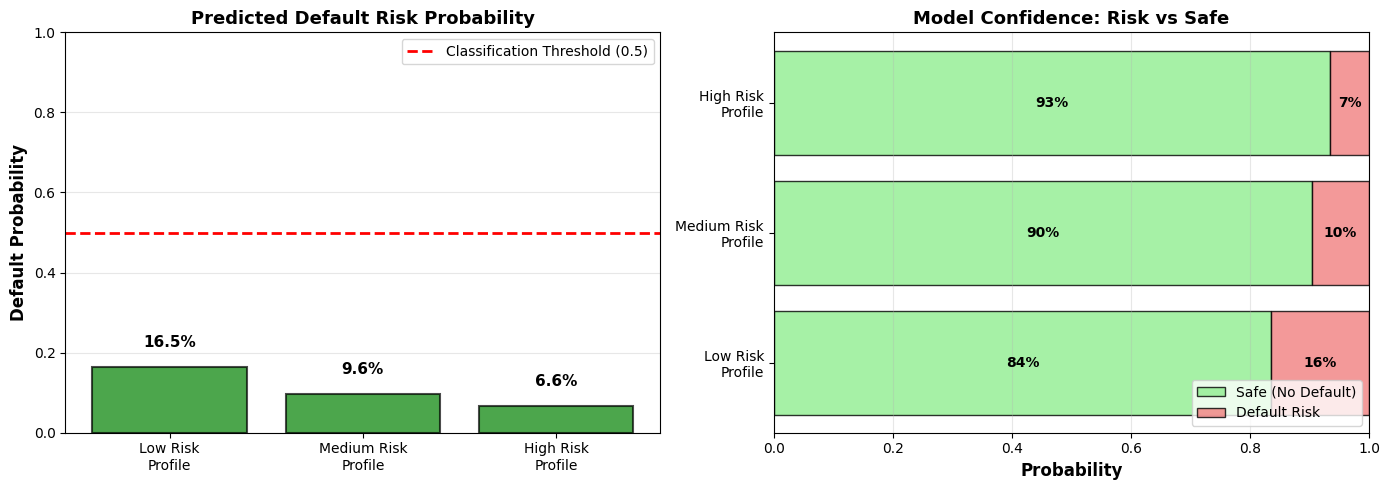


MODEL INFERENCE COMPLETE


In [13]:
# Make predictions on sample cases
print("=== Making Predictions ===\n")

# Scale the features using the loaded scaler
sample_scaled = loaded_scaler.transform(sample_cases)

# Get predictions and probabilities
predictions = loaded_model.predict(sample_scaled)
probabilities = loaded_model.predict_proba(sample_scaled)

# Create results dataframe
results_df = pd.DataFrame({
    'Case': ['Case 1: Low Risk', 'Case 2: Medium Risk', 'Case 3: High Risk'],
    'Prediction': ['No Default' if p == 0 else 'Default' for p in predictions],
    'Default Probability': probabilities[:, 1],
    'No Default Probability': probabilities[:, 0],
})

print(results_df.to_string(index=False))

# Detailed predictions
print("\n" + "="*80)
print("DETAILED PREDICTION RESULTS")
print("="*80)

for i, case in enumerate(['Case 1: Low Risk Profile', 'Case 2: Medium Risk Profile', 'Case 3: High Risk Profile']):
    prob_default = probabilities[i, 1]
    pred_label = 'DEFAULT RISK' if predictions[i] == 1 else 'SAFE'
    
    print(f"\n{case}")
    print("-" * 80)
    print(f"Prediction: {pred_label}")
    print(f"Default Probability: {prob_default:.2%}")
    print(f"Safe Probability: {probabilities[i, 0]:.2%}")
    
    if prob_default < 0.3:
        risk_level = "LOW RISK ✓"
    elif prob_default < 0.6:
        risk_level = "MEDIUM RISK ⚠"
    else:
        risk_level = "HIGH RISK ✗"
    
    print(f"Risk Assessment: {risk_level}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of probabilities
ax1 = axes[0]
cases = ['Low Risk\nProfile', 'Medium Risk\nProfile', 'High Risk\nProfile']
default_probs = probabilities[:, 1]
colors = ['green' if p < 0.3 else 'orange' if p < 0.6 else 'red' for p in default_probs]

ax1.bar(cases, default_probs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Classification Threshold (0.5)')
ax1.set_ylabel('Default Probability', fontsize=12, fontweight='bold')
ax1.set_title('Predicted Default Risk Probability', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add probability labels on bars
for i, (case, prob) in enumerate(zip(cases, default_probs)):
    ax1.text(i, prob + 0.05, f'{prob:.1%}', ha='center', fontsize=11, fontweight='bold')

# Stacked bar chart
ax2 = axes[1]
safe_probs = probabilities[:, 0]
ax2.barh(cases, safe_probs, label='Safe (No Default)', color='lightgreen', alpha=0.8, edgecolor='black')
ax2.barh(cases, default_probs, left=safe_probs, label='Default Risk', color='lightcoral', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Probability', fontsize=12, fontweight='bold')
ax2.set_title('Model Confidence: Risk vs Safe', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim([0, 1])
ax2.grid(axis='x', alpha=0.3)

# Add percentage labels
for i in range(len(cases)):
    ax2.text(safe_probs[i]/2, i, f'{safe_probs[i]:.0%}', ha='center', va='center', fontweight='bold', fontsize=10)
    ax2.text(safe_probs[i] + default_probs[i]/2, i, f'{default_probs[i]:.0%}', ha='center', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("MODEL INFERENCE COMPLETE")
print("="*80)